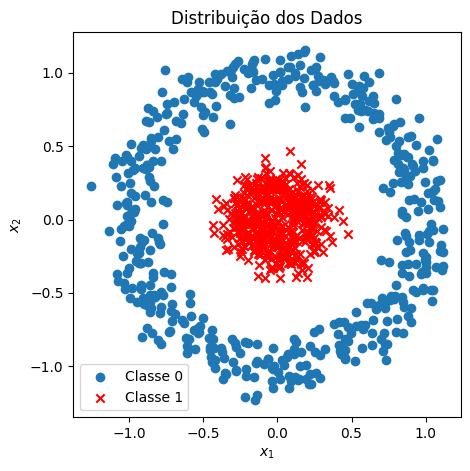

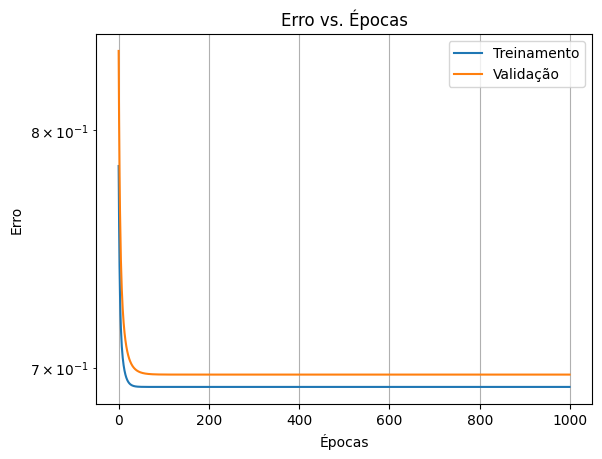

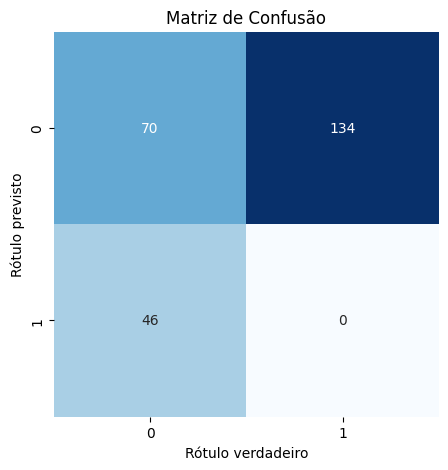

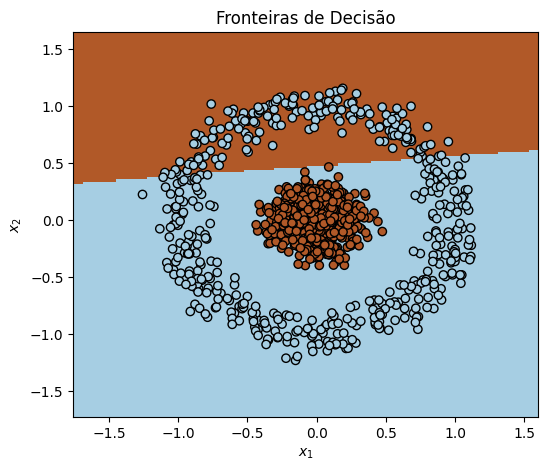

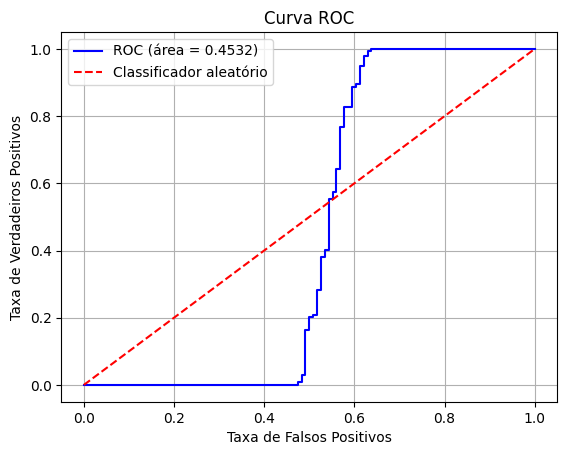

              precision    recall  f1-score   support

           0       0.34      0.60      0.44       116
           1       0.00      0.00      0.00       134

    accuracy                           0.28       250
   macro avg       0.17      0.30      0.22       250
weighted avg       0.16      0.28      0.20       250



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from scipy.special import expit

# Gerar os dados com círculos concêntricos
x, y = make_circles(n_samples=1000, random_state=42, noise=0.1, factor=0.2)
Y = y.copy()  # Guardar para gráfico de cores
y = y.reshape(len(y), 1)  # Formato esperado

# Separar treino e teste
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=23)
x_train_lin = np.c_[np.ones((len(y_train), 1)), x_train]
x_test_lin = np.c_[np.ones((len(y_test), 1)), x_test]

# Função de erro log-loss
def error_function(x, a, y):
    h = expit(x.dot(a))
    return -(1/len(y)) * np.sum(y.T.dot(np.log(h)) + (1 - y).T.dot(np.log(1 - h)))

# Classificador binário (limiar 0.5)
def classifier(x, a):
    h = expit(x.dot(a))
    return (h >= 0.5).astype(float)

# Previsão com probabilidades para ROC
def predict_prob(x, a):
    h1 = expit(x.dot(a))
    h0 = 1 - h1
    return np.c_[h0, h1]

# (a) Plotar dados
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(x[Y==0,0], x[Y==0,1], label='Classe 0')
ax.scatter(x[Y==1,0], x[Y==1,1], label='Classe 1', marker='x', color='red')
ax.set_title("Distribuição dos Dados")
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()
plt.show()



# (c) Treinamento com gradiente descendente em batelada
alpha = 1.0
n_iterations = 1000
a = np.random.randn(x_train_lin.shape[1], 1)
Jgd, Jgd_v = np.zeros(n_iterations+1), np.zeros(n_iterations+1)
Jgd[0] = error_function(x_train_lin, a, y_train)
Jgd_v[0] = error_function(x_test_lin, a, y_test)

minimum_val_error = float("inf")
for iteration in range(n_iterations):
    gradients = -1/len(y_train) * x_train_lin.T.dot(y_train - expit(x_train_lin.dot(a)))
    a = a - alpha * gradients
    Jgd[iteration+1] = error_function(x_train_lin, a, y_train)
    Jgd_v[iteration+1] = error_function(x_test_lin, a, y_test)
    if Jgd_v[iteration+1] < minimum_val_error:
        minimum_val_error = Jgd_v[iteration+1]
        a_min = a.copy()

# (c) Plot erro vs iteração
plt.plot(np.arange(0, n_iterations), Jgd[:n_iterations], label='Treinamento')
plt.plot(np.arange(0, n_iterations), Jgd_v[:n_iterations], label='Validação')
plt.yscale('log')
plt.xlabel('Épocas')
plt.ylabel('Erro')
plt.title('Erro vs. Épocas')
plt.legend()
plt.grid(True)
plt.show()

# (d) Matriz de confusão
y_pred_class = classifier(x_test_lin, a_min)
plt.figure(figsize=(5,5))
mat = confusion_matrix(y_test, y_pred_class)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=['0','1'], yticklabels=['0','1'], cmap="Blues")
plt.xlabel('Rótulo verdadeiro')
plt.ylabel('Rótulo previsto')
plt.title('Matriz de Confusão')
plt.show()

# (e) Fronteiras de decisão
x_min, x_max = x[:, 0].min() - .5, x[:, 0].max() + .5
y_min, y_max = x[:, 1].min() - .5, x[:, 1].max() + .5
h = .02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = classifier(np.c_[np.ones((len(xx.ravel()), 1)), xx.ravel(), yy.ravel()], a_min)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)
plt.scatter(x[:, 0], x[:, 1], c=Y, edgecolors='k', cmap=plt.cm.Paired)
plt.title('Fronteiras de Decisão')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()

# (f) Curva ROC
y_prob = predict_prob(x_test_lin, a_min)
fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', label='ROC (área = {:.4f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Classificador aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

# (g) Métricas
relatorio = classification_report(y_test, y_pred_class, output_dict=False)
print(relatorio)


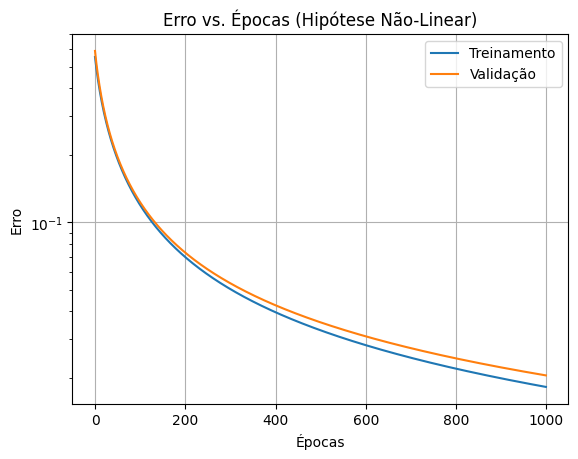

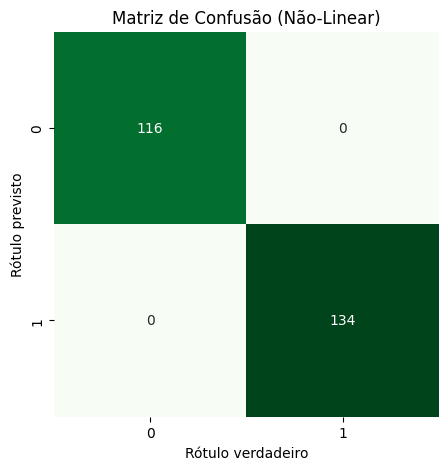

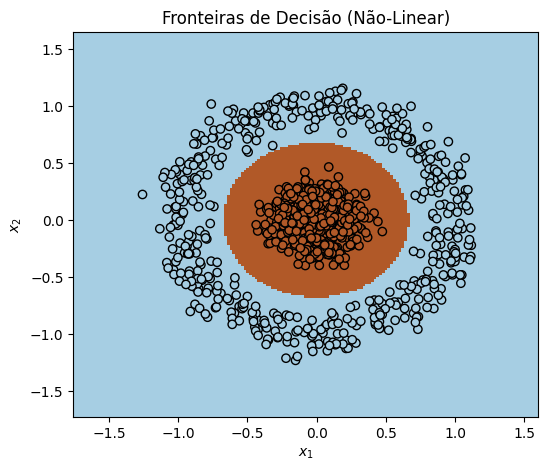

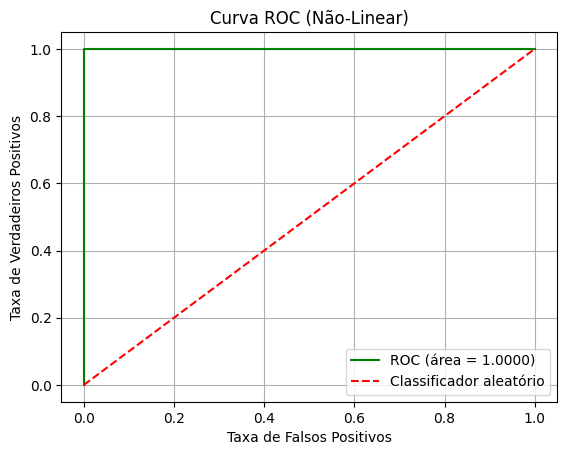

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       116
           1       1.00      1.00      1.00       134

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



In [2]:
# Adicionando os termos quadráticos x1^2 e x2^2 na entrada
x_train_nlin = np.c_[np.ones((len(y_train), 1)),
                     x_train,
                     x_train[:, 0]**2,
                     x_train[:, 1]**2]

x_test_nlin = np.c_[np.ones((len(y_test), 1)),
                    x_test,
                    x_test[:, 0]**2,
                    x_test[:, 1]**2]

# Inicialização dos pesos
a = np.random.randn(x_train_nlin.shape[1], 1)

# Parâmetros do treinamento
alpha = 1.0
n_iterations = 1000
Jgd_nlin = np.zeros(n_iterations+1)
Jgd_v_nlin = np.zeros(n_iterations+1)
Jgd_nlin[0] = error_function(x_train_nlin, a, y_train)
Jgd_v_nlin[0] = error_function(x_test_nlin, a, y_test)

minimum_val_error = float("inf")
for iteration in range(n_iterations):
    gradients = -1/len(y_train) * x_train_nlin.T.dot(y_train - expit(x_train_nlin.dot(a)))
    a = a - alpha * gradients
    Jgd_nlin[iteration+1] = error_function(x_train_nlin, a, y_train)
    Jgd_v_nlin[iteration+1] = error_function(x_test_nlin, a, y_test)
    if Jgd_v_nlin[iteration+1] < minimum_val_error:
        minimum_val_error = Jgd_v_nlin[iteration+1]
        a_min_nlin = a.copy()

# Plot erro vs iteração para hipótese não-linear
plt.plot(np.arange(0, n_iterations), Jgd_nlin[:n_iterations], label='Treinamento')
plt.plot(np.arange(0, n_iterations), Jgd_v_nlin[:n_iterations], label='Validação')
plt.yscale('log')
plt.xlabel('Épocas')
plt.ylabel('Erro')
plt.title('Erro vs. Épocas (Hipótese Não-Linear)')
plt.legend()
plt.grid(True)
plt.show()

# Matriz de confusão
y_pred_class_nlin = classifier(x_test_nlin, a_min_nlin)
plt.figure(figsize=(5,5))
mat = confusion_matrix(y_test, y_pred_class_nlin)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=['0','1'], yticklabels=['0','1'], cmap="Greens")
plt.xlabel('Rótulo verdadeiro')
plt.ylabel('Rótulo previsto')
plt.title('Matriz de Confusão (Não-Linear)')
plt.show()

# Fronteiras de decisão para hipótese não-linear
Z = classifier(np.c_[np.ones((len(xx.ravel()), 1)),
                     xx.ravel(), yy.ravel(),
                     xx.ravel()**2, yy.ravel()**2], a_min_nlin)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)
plt.scatter(x[:, 0], x[:, 1], c=Y, edgecolors='k', cmap=plt.cm.Paired)
plt.title('Fronteiras de Decisão (Não-Linear)')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()

# Curva ROC para hipótese não-linear
y_prob_nlin = predict_prob(x_test_nlin, a_min_nlin)
fpr_nlin, tpr_nlin, _ = roc_curve(y_test, y_prob_nlin[:, 1])
roc_auc_nlin = auc(fpr_nlin, tpr_nlin)
plt.plot(fpr_nlin, tpr_nlin, color='green', label='ROC (área = {:.4f})'.format(roc_auc_nlin))
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Classificador aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC (Não-Linear)')
plt.legend()
plt.grid(True)
plt.show()

# Métricas para hipótese não-linear
relatorio_nlin = classification_report(y_test, y_pred_class_nlin, output_dict=False)
print(relatorio_nlin)


i.Qual a diferença na performance do classificador entre as duas funções hipóteses?

R:A hipótese não-linear da ao classificador melhoria em desempenho, sendo essencial para problemas com dados não linearmente separáveis, como círculos concêntricos.